In [38]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
#Define output directory for the data
datadir = '/home/jovyan/SAMBBA_data/'

In [5]:
with open(datadir+'/man-ams_faam_20120929_r0_b746.na', "rb") as f:
    lines = f.readlines()  # Read the first 100 bytes
print(lines[:45])  # Print the first 5 lines

[b'46 1001\r\n', b'Will Morgan, James Allan\r\n', b'School of Earth, Atmospheric and Environmental Science, The University of Manchester\r\n', b'AMS Aerosol Concentrations from FAAM BAE-146\r\n', b'SAMBBA\r\n', b'1 1\r\n', b'2012 09 29 2014 04 04\r\n', b'0\r\n', b'Time_start_UTC (seconds from 0000 UTC on start day)\r\n', b'12\r\n', b'1 1 1 1 1 1 1 1 1 1 1 1 \r\n', b'9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 \r\n', b'Time_end_UTC (seconds from 0000 UTC on start day)\r\n', b'Time_mid_UTC (seconds from 0000 UTC on start day)\r\n', b'Sulphate\r\n', b'Ammonium\r\n', b'Organics\r\n', b'Nitrate\r\n', b'Chloride\r\n', b'Sulphate uncertainty\r\n', b'Ammonium uncertainty\r\n', b'Organic uncertainty\r\n', b'Nitrate uncertainty\r\n', b'Chloride uncertainty\r\n', b'16\r\n', b'PI_CONTACT_INFO: Centre for Atmospheric Science, School of Earth, Atmospheric and Environmental Science, University of Manchester, Simon Building, Oxford Road, Manchester, 

In [27]:
metadata_lines = lines[:46]  # Assume first 5 lines are metadata
header_line = metadata_lines[45].strip().split()  # Extract header names
# Decode if header contains byte strings
header_line = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line]
# Decode if metadata contains byte strings
metadata_lines = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines]
metadata_lines

['46 1001',
 'Will Morgan, James Allan',
 'School of Earth, Atmospheric and Environmental Science, The University of Manchester',
 'AMS Aerosol Concentrations from FAAM BAE-146',
 'SAMBBA',
 '1 1',
 '2012 09 29 2014 04 04',
 '0',
 'Time_start_UTC (seconds from 0000 UTC on start day)',
 '12',
 '1 1 1 1 1 1 1 1 1 1 1 1',
 '9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999',
 'Time_end_UTC (seconds from 0000 UTC on start day)',
 'Time_mid_UTC (seconds from 0000 UTC on start day)',
 'Sulphate',
 'Ammonium',
 'Organics',
 'Nitrate',
 'Chloride',
 'Sulphate uncertainty',
 'Ammonium uncertainty',
 'Organic uncertainty',
 'Nitrate uncertainty',
 'Chloride uncertainty',
 '16',
 'PI_CONTACT_INFO: Centre for Atmospheric Science, School of Earth, Atmospheric and Environmental Science, University of Manchester, Simon Building, Oxford Road, Manchester, M13 9PL ; william.morgan@manchester.ac.uk; 44-161-306-6586',
 'PLATFORM: FAAM BAE146',
 'LOCATION: See 

In [28]:
data_lines = lines[46:]  # Actual data starts after metadata

In [29]:
# Print extracted metadata and headers
for i, line in enumerate(metadata_lines[:45], 1):  # Exclude header itself
    print(f"Metadata {i}: {line.strip()}")

print(f"Header: {header_line}")

Metadata 1: 46 1001
Metadata 2: Will Morgan, James Allan
Metadata 3: School of Earth, Atmospheric and Environmental Science, The University of Manchester
Metadata 4: AMS Aerosol Concentrations from FAAM BAE-146
Metadata 5: SAMBBA
Metadata 6: 1 1
Metadata 7: 2012 09 29 2014 04 04
Metadata 8: 0
Metadata 9: Time_start_UTC (seconds from 0000 UTC on start day)
Metadata 10: 12
Metadata 11: 1 1 1 1 1 1 1 1 1 1 1 1
Metadata 12: 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999 9999999
Metadata 13: Time_end_UTC (seconds from 0000 UTC on start day)
Metadata 14: Time_mid_UTC (seconds from 0000 UTC on start day)
Metadata 15: Sulphate
Metadata 16: Ammonium
Metadata 17: Organics
Metadata 18: Nitrate
Metadata 19: Chloride
Metadata 20: Sulphate uncertainty
Metadata 21: Ammonium uncertainty
Metadata 22: Organic uncertainty
Metadata 23: Nitrate uncertainty
Metadata 24: Chloride uncertainty
Metadata 25: 16
Metadata 26: PI_CONTACT_INFO: Centre for Atmospheric Science,

In [34]:
# Parse data into a NumPy array
data_array = np.array([line.strip().split() for line in data_lines], dtype=float)

# Define dimensions (assuming first column is time and others are variables)
dims = ("time", "variable")  # Modify as needed
time_coords = np.arange(data_array.shape[0])  # Placeholder for time index

# Convert to xarray Dataset with headers as variable names
ds = xr.Dataset(
    {name: ("time", data_array[:, i]) for i, name in enumerate(header_line)},
    coords={"time": time_coords},
    attrs={"Metadata": "\n".join(metadata_lines[:45])}  # Store metadata as an attribute
)

ds

<xarray.Dataset> Size: 257kB
Dimensions:          (time: 2297)
Coordinates:
  * time             (time) int64 18kB 0 1 2 3 4 5 ... 2292 2293 2294 2295 2296
Data variables: (12/13)
    Time_start_UTC   (time) float64 18kB 4.311e+04 4.314e+04 ... 5.997e+04
    Time_end_UTC     (time) float64 18kB 4.314e+04 4.317e+04 ... 5.998e+04
    Time_mid_UTC     (time) float64 18kB 4.312e+04 4.316e+04 ... 5.997e+04
    SO4              (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.1453 0.1977
    NH4              (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.07279 0.0649
    ORG              (time) float64 18kB 1e+07 1e+07 1e+07 ... 2.248 1.959 2.106
    ...               ...
    Chl              (time) float64 18kB 1e+07 1e+07 ... -0.001078 -0.000271
    SO4_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.01538 0.01561
    NH4_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.03741 0.03713
    ORG_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.05868 0.05833
    NO3_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.009552 0.009425
    Chl_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.005893 0.005934
Attributes:
    Metadata:  46 1001\nWill Morgan, James Allan\nSchool of Earth, Atmospheri...

In [42]:
def convert_time_to_datetime(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y %m %d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf

# Example usage
start_date = "2012 09 29"  # Example start date

# Convert time
ds0 = convert_time_to_datetime(ds, start_date)

# Print updated dataset with datetime coordinate
ds0


<xarray.Dataset> Size: 276kB
Dimensions:          (time: 2297)
Coordinates:
  * time             (time) int64 18kB 0 1 2 3 4 5 ... 2292 2293 2294 2295 2296
    datetime         (time) datetime64[ns] 18kB 2012-09-29T11:58:29 ... 2012-...
Data variables: (12/13)
    Time_start_UTC   (time) float64 18kB 4.311e+04 4.314e+04 ... 5.997e+04
    Time_end_UTC     (time) float64 18kB 4.314e+04 4.317e+04 ... 5.998e+04
    Time_mid_UTC     (time) float64 18kB 4.312e+04 4.316e+04 ... 5.997e+04
    SO4              (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.1453 0.1977
    NH4              (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.07279 0.0649
    ORG              (time) float64 18kB 1e+07 1e+07 1e+07 ... 2.248 1.959 2.106
    ...               ...
    Chl              (time) float64 18kB 1e+07 1e+07 ... -0.001078 -0.000271
    SO4_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.01538 0.01561
    NH4_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.03741 0.03713
    ORG_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.05868 0.05833
    NO3_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.009552 0.009425
    Chl_uncertainty  (time) float64 18kB 1e+07 1e+07 1e+07 ... 0.005893 0.005934
Attributes:
    Metadata:  46 1001\nWill Morgan, James Allan\nSchool of Earth, Atmospheri...

In [59]:
# Filter out invalid SO4 values (9999999)
valid_SO4_mask = ds0["SO4"] != 9999999
filtered_ds_SO4 = ds0.where(valid_SO4_mask, drop=True)

# Filter out invalid NH4 values (9999999)
valid_NH4_mask = ds0["NH4"] != 9999999
filtered_ds_NH4 = ds0.where(valid_NH4_mask, drop=True)

# Filter out invalid ORG values (9999999)
valid_ORG_mask = ds0["ORG"] != 9999999
filtered_ds_ORG = ds0.where(valid_ORG_mask, drop=True)

# Filter out invalid NO3 values (9999999)
valid_NO3_mask = ds0["NO3"] != 9999999
filtered_ds_NO3 = ds0.where(valid_NO3_mask, drop=True)


# Filter out invalid Chl values (9999999)
valid_Chl_mask = ds0["Chl"] != 9999999
filtered_ds_Chl = ds0.where(valid_Chl_mask, drop=True)

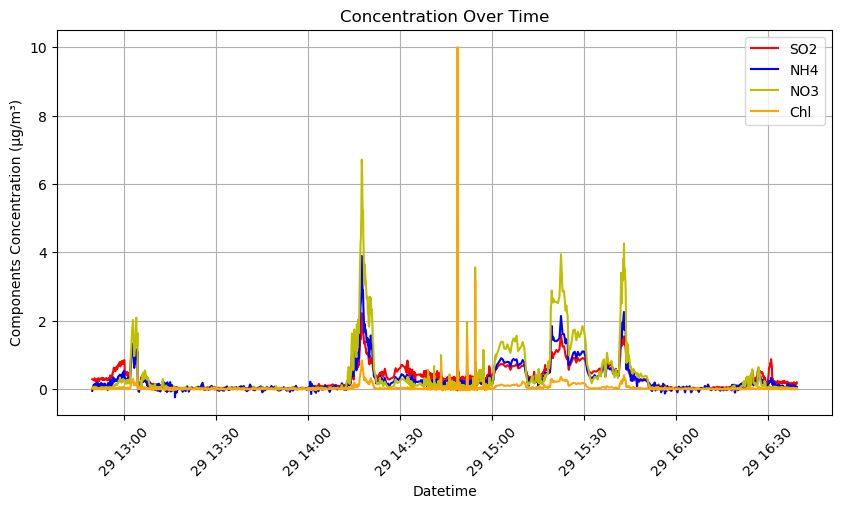

In [58]:



# Plot SO4 vs. datetime
plt.figure(figsize=(10, 5))
plt.plot(filtered_ds_SO4.datetime, filtered_ds_SO4["SO4"], label="SO2", color="r")
plt.plot(filtered_ds_NH4.datetime, filtered_ds_NH4["NH4"], label="NH4", color="b")
#plt.plot(filtered_ds_ORG.datetime, filtered_ds_ORG["ORG"], label="ORG", color="g")
plt.plot(filtered_ds_NO3.datetime, filtered_ds_NO3["NO3"], label="NO3", color="y")
plt.plot(filtered_ds_Chl.datetime, filtered_ds_Chl["Chl"], label="Chl", color="orange")

# Formatting
plt.xlabel("Datetime")
plt.ylabel("Components Concentration (µg/m³)")
plt.title("Concentration Over Time")
plt.xticks(rotation=45)
plt.grid()
plt.legend()

# Show plot
plt.show()